# Figure 3. Cardiomyocyte regional heterogeneity and transmurality

6 panels of this figure are built below, one section each.

---

## Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']
import sys
sys.path[:0] = ["../src", "../figures/_lib", "../figures/Fig3"]
from hhca.paths import TABLES, OUT
print('inputs :', TABLES)
print('outputs:', OUT)

inputs : /Volumes/Storage/hhca_spatial_tables
outputs: /Users/maiia.shulman/hhca_release_out


## Fig3 c

Fig 3c — snRNA-derived cardiomyocyte chamber panel across chamber Visium slides, CM-dominant spots only

Input:
- `heart_results/chamber_panel_allslides/cm_dominant/tables/CMdominant_region_zscore.csv`
- `heart_results/chamber_panel_allslides/cm_dominant/tables/CMdominant_spot_fractions_by_region.csv`
- `scanpy_analysis/chamber_specificity/concordance/tables/concordance_per_gene.csv  (atria / ventricle gene direction)`

Source: `figures/Fig3/panel_c.py`

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved c | 12 atrial + 5 ventricular genes | CM-dominant spots: {'LA': 9292, 'RA': 8336, 'LV': 19631, 'RV': 8277}


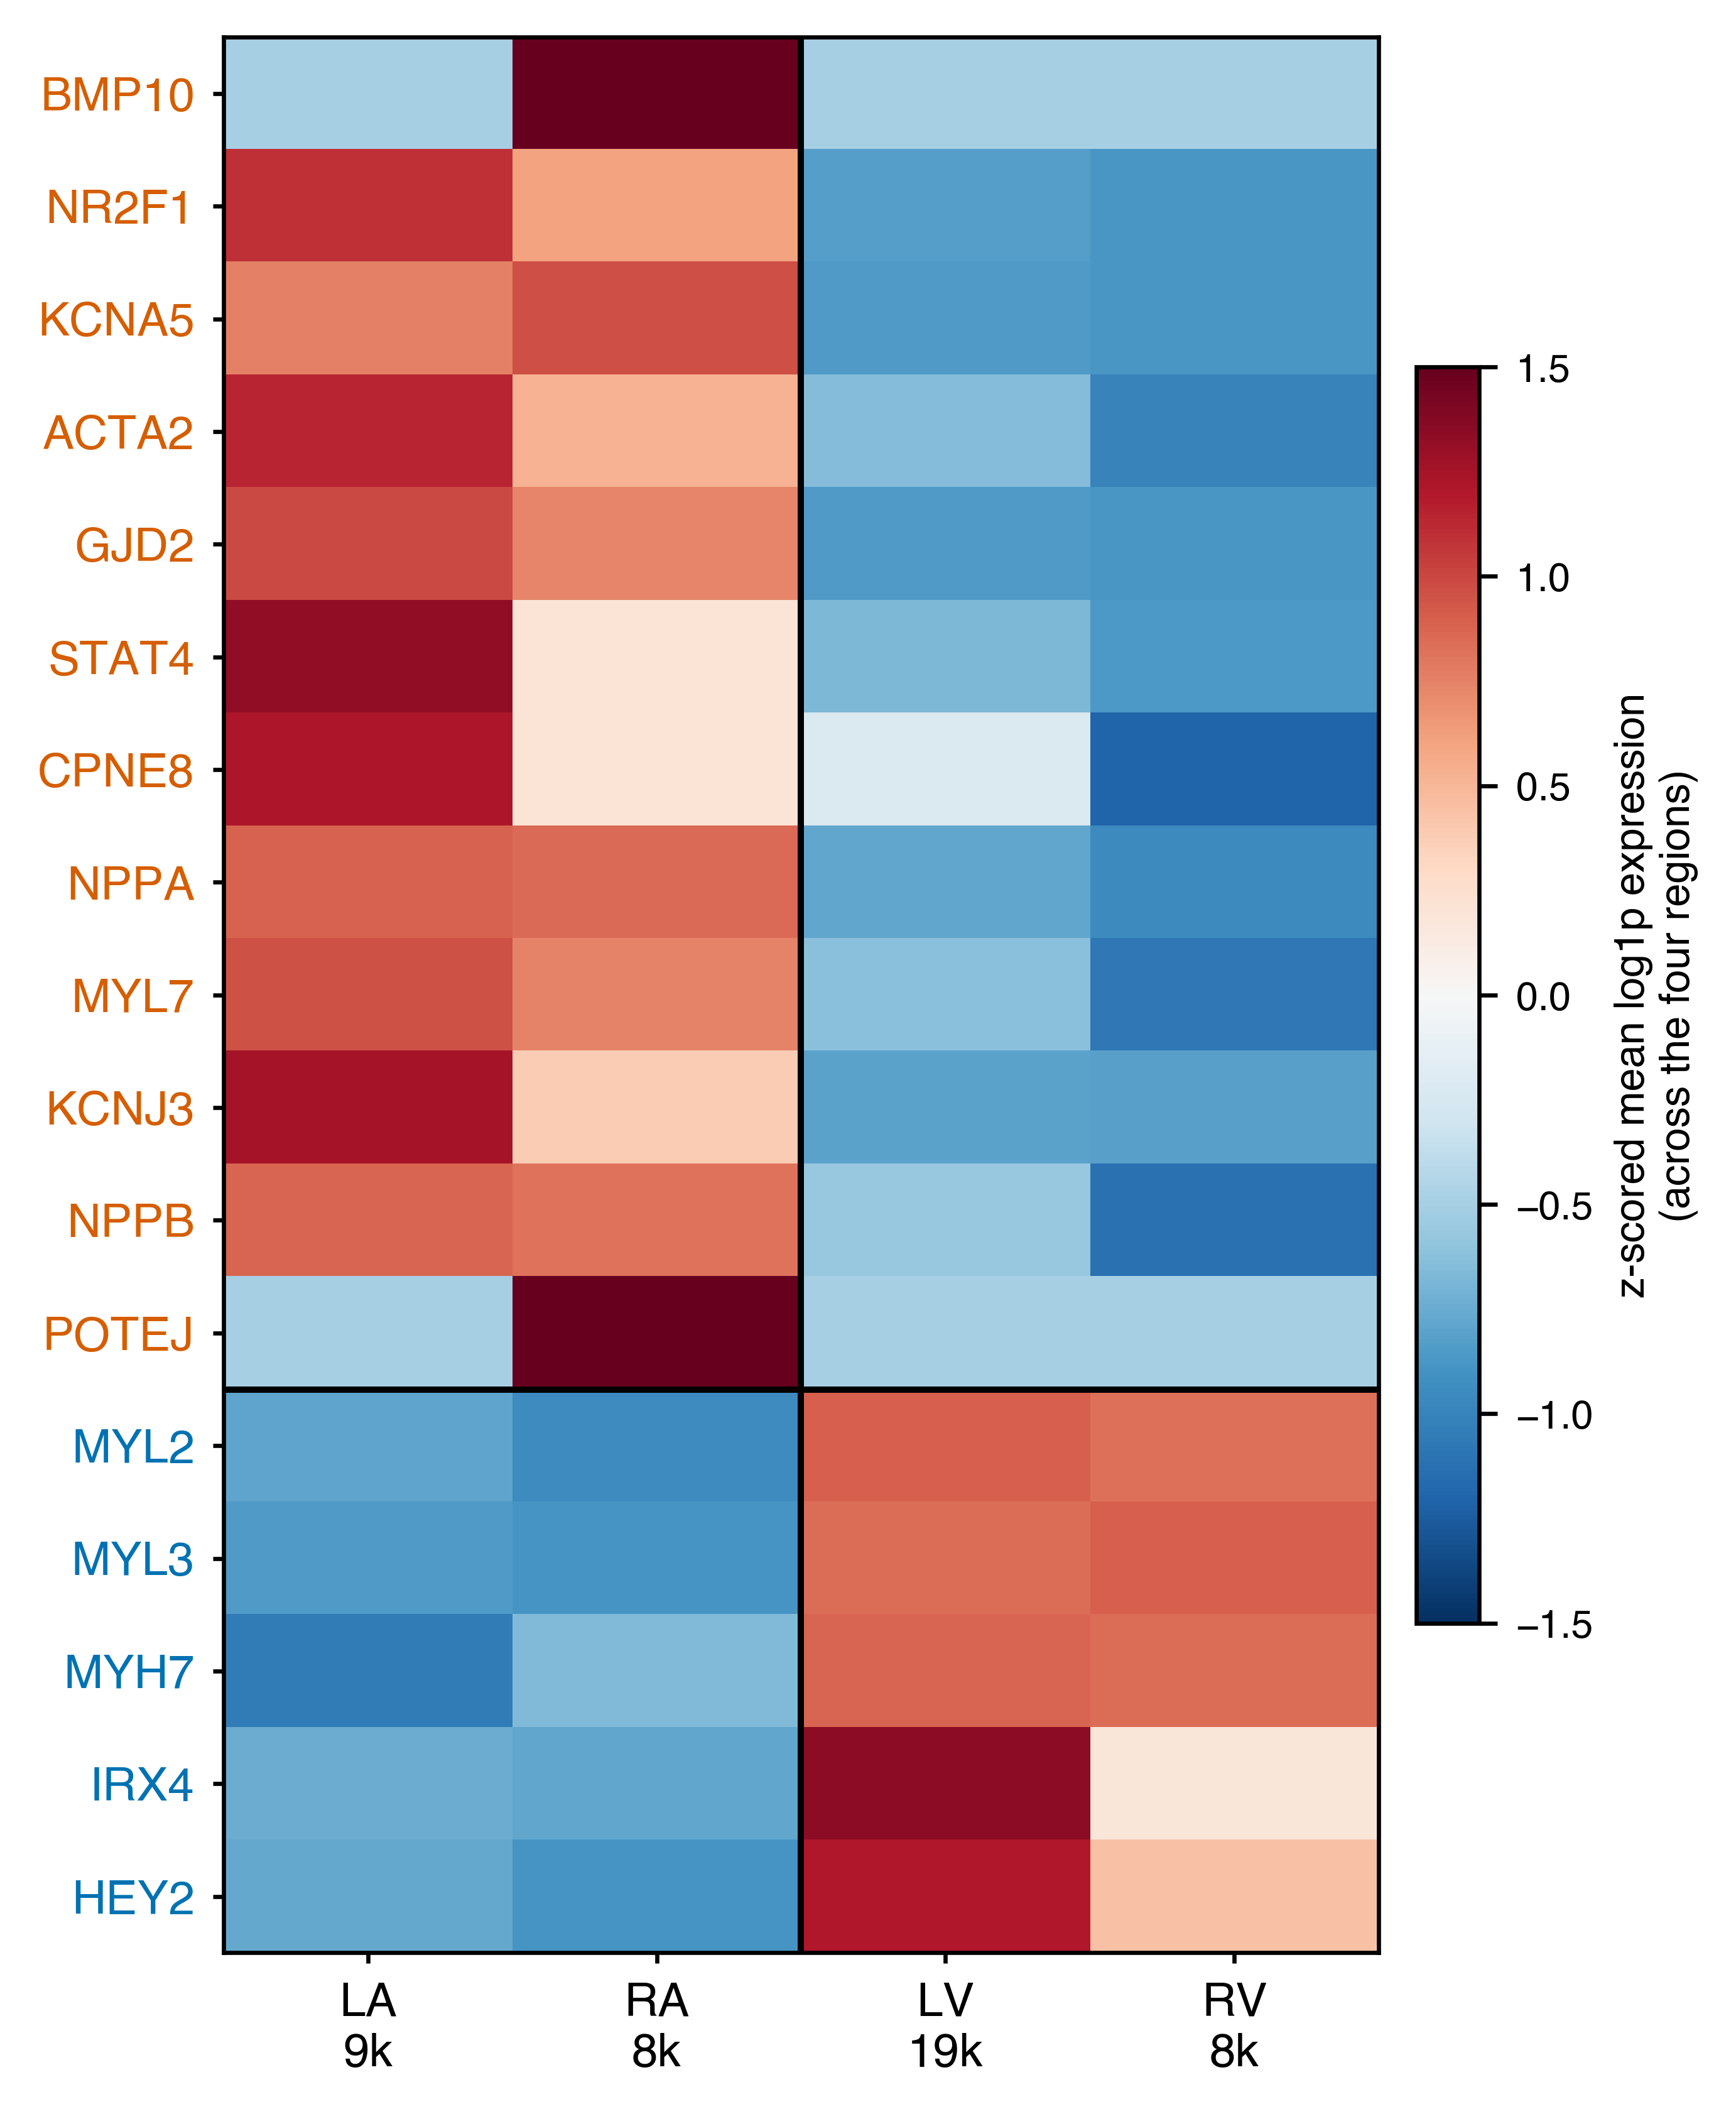

In [2]:
from hhca.paths import TABLES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pubfig import save

TAB = f"{TABLES}/heart_results/chamber_panel_allslides/cm_dominant/tables"
CONC = f"{TABLES}/scanpy_analysis/chamber_specificity/concordance/tables/concordance_per_gene.csv"
REGIONS = ["LA", "RA", "LV", "RV"]
C_ATR, C_VEN = "#D55E00", "#0072B2"
POTEJ = "POTEJ"

Z = pd.read_csv(f"{TAB}/CMdominant_region_zscore.csv", index_col=0)[REGIONS]
gene_order = list(Z.index)
reg = pd.read_csv(f"{TAB}/CMdominant_spot_fractions_by_region.csv").set_index("region")
cm_n = {r: int(reg.loc[r, "combined_cm"]) for r in REGIONS}
snuc_dir = pd.read_csv(CONC).drop_duplicates("gene").set_index("gene")["snuc_dir"].reindex(gene_order)
n_atr = int((snuc_dir == "atria").sum())          # atrial block incl. POTEJ; ventricular genes below the rule

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
                     "font.size": 9, "axes.linewidth": 0.8, "figure.dpi": 300, "pdf.fonttype": 42})
COL = {"atria": C_ATR, "ventricle": C_VEN}

fig, ax = plt.subplots(figsize=(4.3, 6.6))
vmax = float(np.nanmax(np.abs(Z.values)))
im = ax.imshow(Z.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels([f"{r}\n{cm_n[r] // 1000}k" if cm_n[r] >= 1000 else f"{r}\n{cm_n[r]}" for r in REGIONS])
ax.set_yticks(range(len(gene_order)))
ax.set_yticklabels(gene_order)
for t, g in zip(ax.get_yticklabels(), gene_order):
    t.set_color(COL[snuc_dir[g]])
    if g == POTEJ:
        t.set_fontstyle("italic")
        t.set_fontweight("bold")
ax.axhline(n_atr - 0.5, color="black", lw=1.2)
ax.axvline(1.5, color="black", lw=1.2)
ax.tick_params(length=2)
for gi, g in enumerate(gene_order):
    for ri, r in enumerate(REGIONS):
        if not np.isfinite(Z.values[gi, ri]):
            ax.add_patch(plt.Rectangle((ri - 0.5, gi - 0.5), 1, 1, facecolor="0.85", edgecolor="white",
                                       hatch="///", lw=0))
cb = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.03)
cb.set_label("z-scored mean log1p expression\n(across the four regions)", fontsize=8)
cb.ax.tick_params(labelsize=7.5)
save(fig, "Fig3", "c", bbox_inches="tight")
print("saved c |", n_atr, "atrial +", len(gene_order) - n_atr, "ventricular genes | CM-dominant spots:", cm_n)


## Fig3 d

Fig 3d — ventricular-cardiomyocyte stress score across the wall of donor H0054 (three Visium HD 2 um sections:

Input:
- `storage/Heart_ficture_2um_L3_h5ads/VS_CA_H0054LV_henricke_{epi,myo,endo}.h5ad`
- `storage/CMFLAG_fullmethod_realHE/VS_CA_H0054LV_henricke_{epi,myo,endo}_clean_bins.parquet`
- `heart_results/transmural_stress_newfilter/tables/genesets.json`

Source: `figures/Fig3/panel_d.py`

saved d | fields: {'epi': [np.float64(8996.8), np.float64(9646.8), np.float64(412.3), np.float64(1062.3)], 'myo': [np.float64(3806.6), np.float64(4456.6), np.float64(4955.9), np.float64(5605.9)], 'endo': [np.float64(6917.6), np.float64(7567.6), np.float64(823.0), np.float64(1473.0)]} | whole-section means: {'epi': -0.0131, 'myo': -0.0111, 'endo': 0.0273}


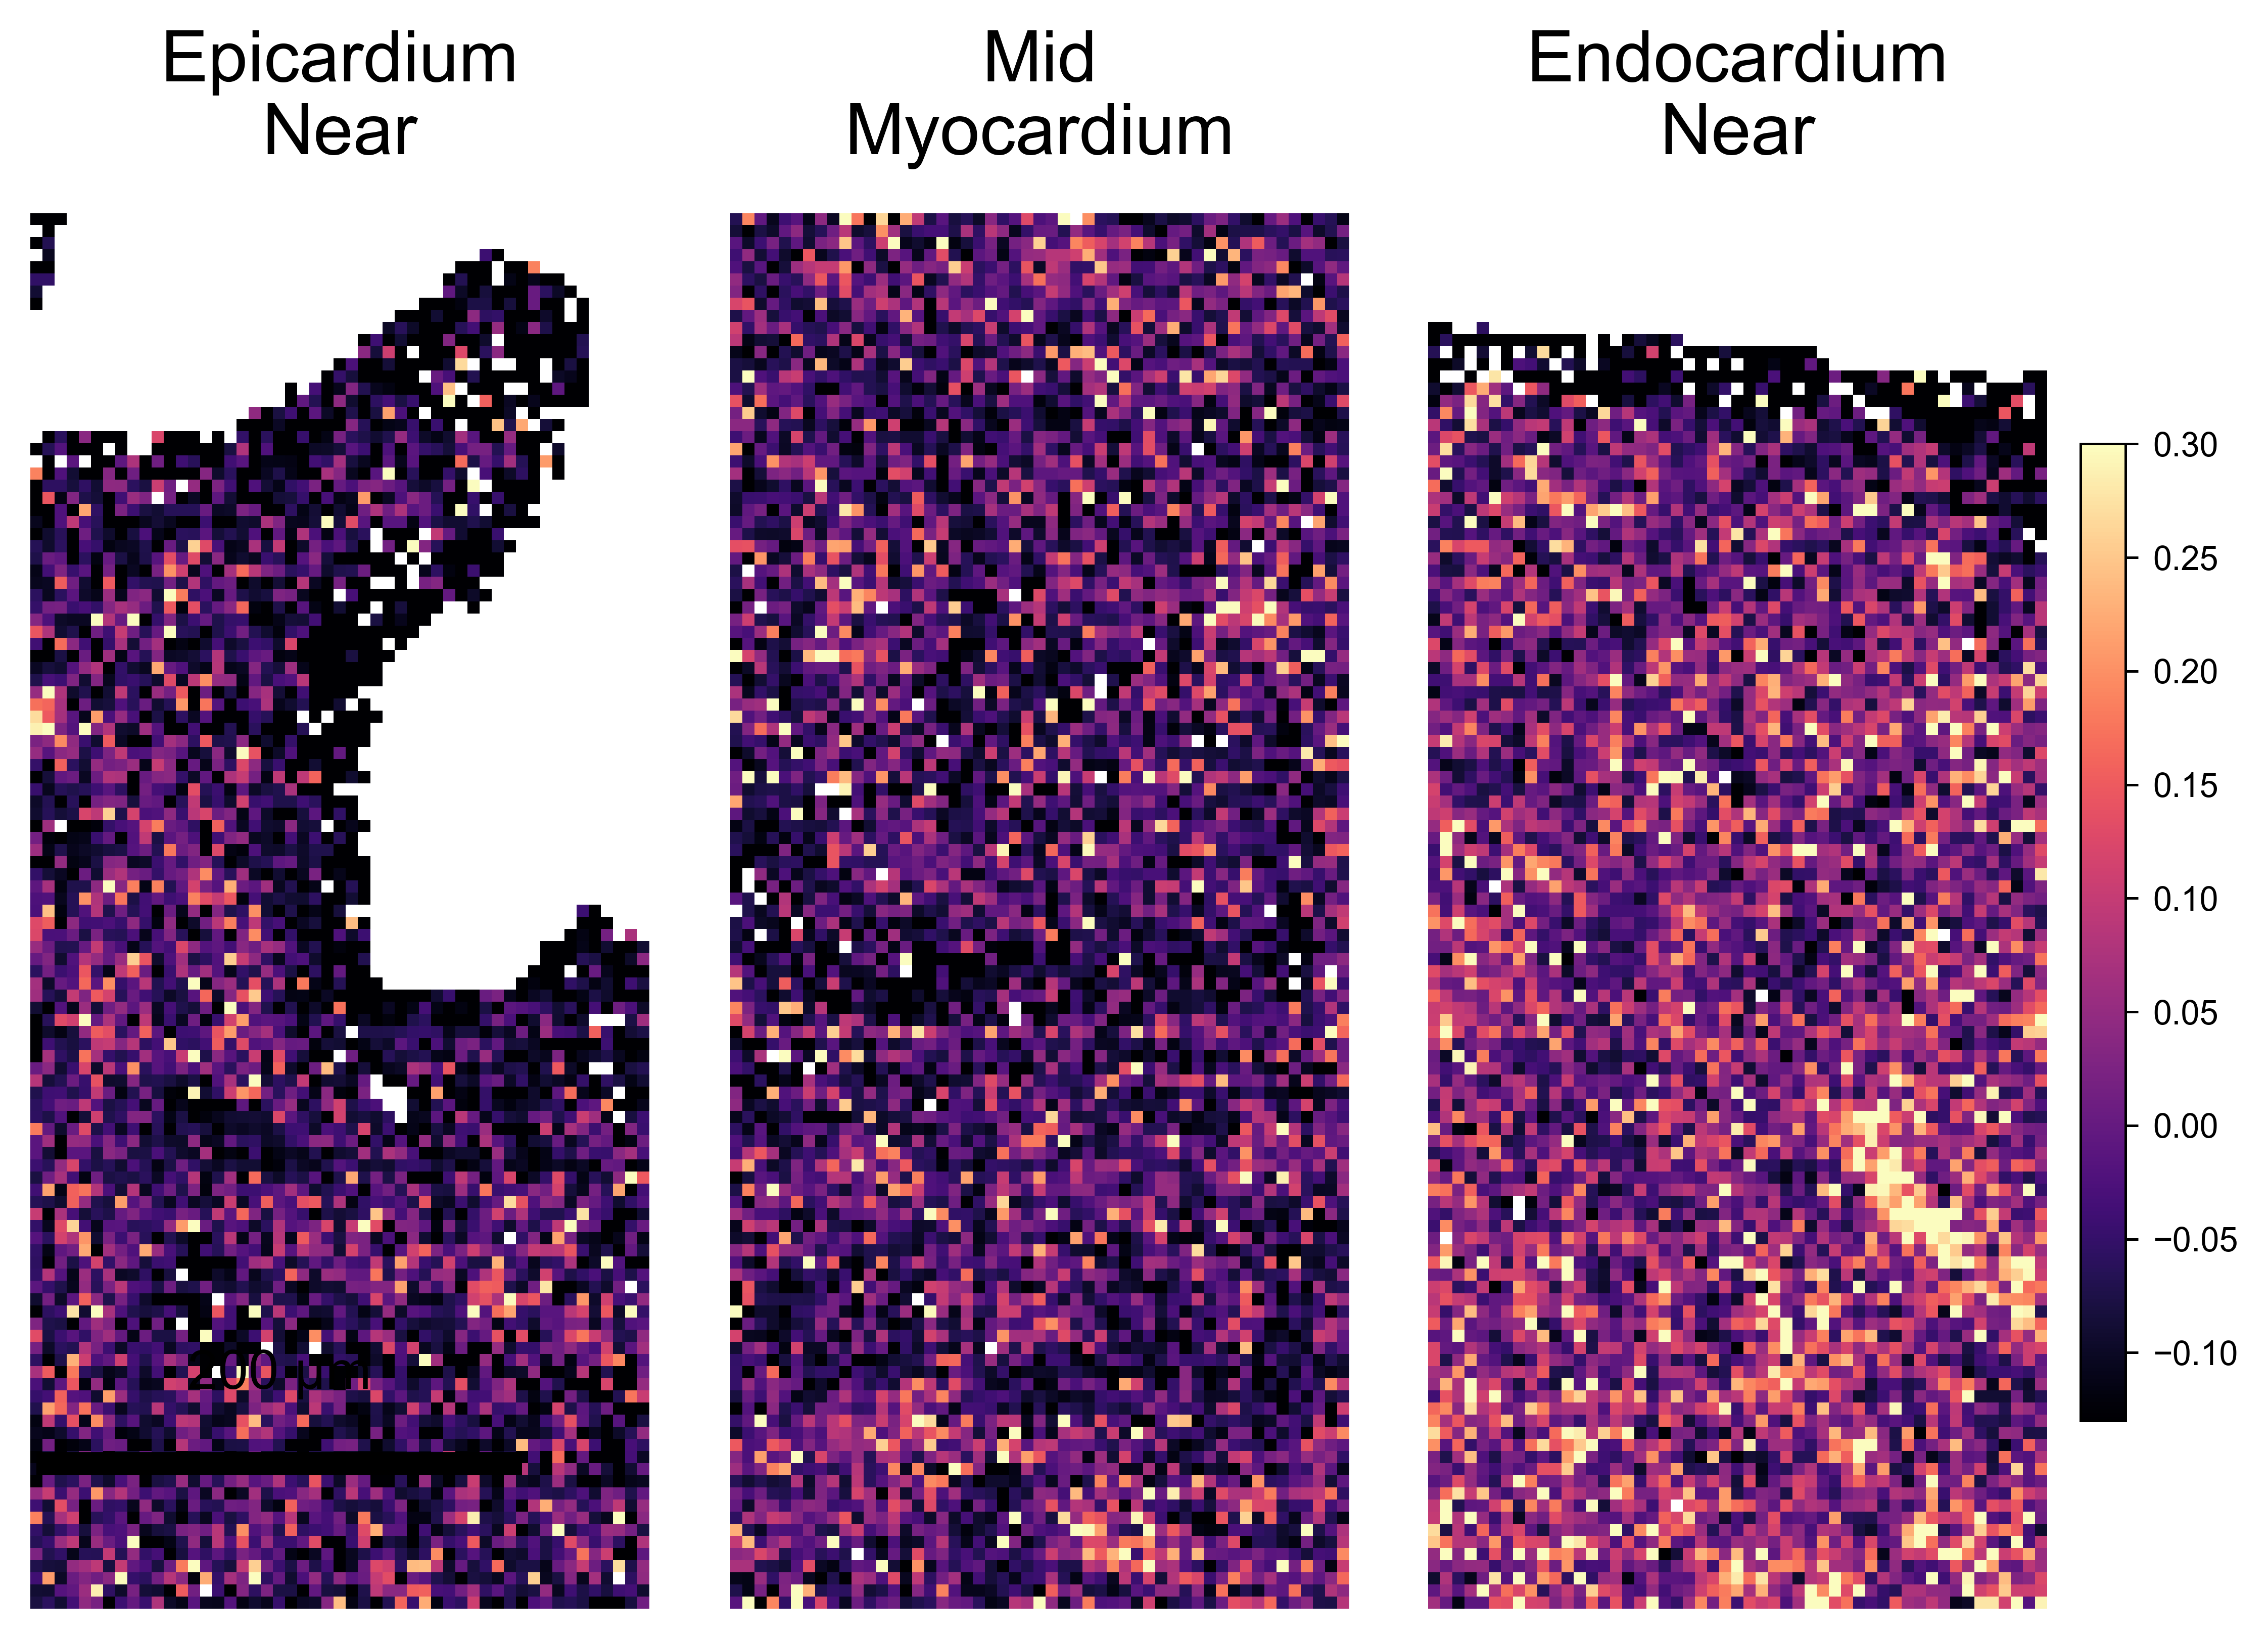

In [3]:
from hhca.paths import REPO, TABLES
import os
import json
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from pubfig import save

H5DIR = f"{TABLES}/storage/Heart_ficture_2um_L3_h5ads"
PQDIR = f"{TABLES}/storage/CMFLAG_fullmethod_realHE"
STRESS = json.load(open(f"{TABLES}/heart_results/transmural_stress_newfilter/tables/genesets.json"))["stress_genes"]
FLAGS = ["flag_cm_spillover", "flag_vsmc_spillover", "flag_spill_artEC", "flag_spill_venEC"]
CACHE = f"{REPO}/.scratch/Fig3"            # optional per-section cache (recomputed if absent)
LAYERS = ["epi", "myo", "endo"]
TITLE = {"epi": "Epicardium\nNear", "myo": "Mid\nMyocardium", "endo": "Endocardium\nNear"}
WIN, GBIN = 650.0, 5.0
PICK = {"epi": 0.10, "myo": 0.50, "endo": 0.90}
VMIN, VMAX = -0.13, 0.30
STRIP_W, STRIP_Y0, STRIP_Y1 = 255.0, 75.0, 650.0                  # printed band of each 650 um field
CHUNK = 250_000


def stream_section(layer):
    """x, y, log1p CP10k of the stress genes for CMFLAG-clean vCM bins, streaming the CSR in row chunks."""
    stem = f"VS_CA_H0054LV_henricke_{layer}"
    cache = f"{CACHE}/stress_{layer}.npz"
    if os.path.exists(cache):
        d = np.load(cache)
        return d["x"], d["y"], d["lg"]
    f = h5py.File(f"{H5DIR}/{stem}.h5ad", "r")
    var = f["var"]["_index"][:].astype(str)
    gi = np.array([int(np.where(var == g)[0][0]) for g in STRESS if g in set(var)])
    x = f["obs"]["x_um"][:].astype(np.float64)
    y = f["obs"]["y_um"][:].astype(np.float64)
    codes = f["obs"]["L3_label"]["codes"][:]
    cats = f["obs"]["L3_label"]["categories"][:].astype(str)
    n, indptr = len(x), f["X"]["indptr"]
    total = np.zeros(n)
    cnt = np.zeros((n, len(gi)), np.float32)
    lut = np.full(len(var), -1)
    lut[gi] = np.arange(len(gi))
    for s in range(0, n, CHUNK):
        e = min(n, s + CHUNK)
        p0, p1 = int(indptr[s]), int(indptr[e])
        dat, ix = f["X"]["data"][p0:p1], f["X"]["indices"][p0:p1]
        rows = np.repeat(np.arange(s, e), np.diff(indptr[s:e + 1]))
        np.add.at(total, rows, dat)
        sel = lut[ix] >= 0
        np.add.at(cnt, (rows[sel], lut[ix[sel]]), dat[sel])
    f.close()
    pq = pd.read_parquet(f"{PQDIR}/{stem}_clean_bins.parquet", columns=["X", "Y"] + FLAGS)
    pq = pq.assign(kx=np.round(pq.X.to_numpy(np.float64), 1), ky=np.round(pq.Y.to_numpy(np.float64), 1),
                   spill=pq[FLAGS].any(axis=1))
    key = pq.drop_duplicates(["kx", "ky"]).set_index(["kx", "ky"])["spill"]
    spill = key.reindex(pd.MultiIndex.from_arrays([np.round(x, 1), np.round(y, 1)])).to_numpy()
    spill = np.where(pd.isna(spill), False, spill).astype(bool)
    cm = (cats[codes] == "Ventricular Cardiomyocytes") & ~spill
    lg = np.log1p(cnt[cm] / np.maximum(total[cm], 1)[:, None] * 1e4).astype(np.float32)
    return x[cm], y[cm], lg


RAW = {L: stream_section(L) for L in LAYERS}
n = sum(lg.shape[0] for _, _, lg in RAW.values())
mu = sum(lg.sum(0, dtype=np.float64) for _, _, lg in RAW.values()) / n
sd = np.sqrt(sum((lg.astype(np.float64) ** 2).sum(0) for _, _, lg in RAW.values()) / n - mu ** 2)
BINS = {L: (RAW[L][0], RAW[L][1], ((RAW[L][2] - mu) / sd).mean(1).astype(np.float32)) for L in LAYERS}
del RAW


def choose_window(L):
    x, y, s = BINS[L]
    gx = np.floor((x - x.min()) / WIN).astype(np.int64)
    gy = np.floor((y - y.min()) / WIN).astype(np.int64)
    BIG = gy.max() + 1
    g = pd.DataFrame({"k": gx * BIG + gy, "s": s}).groupby("k")["s"].agg(["mean", "count"])
    g = g[g["count"] >= 4000].sort_values("mean")
    k = g.iloc[int(np.clip(round(PICK[L] * (len(g) - 1)), 0, len(g) - 1))].name
    wx, wy = k // BIG, k % BIG
    return (x.min() + wx * WIN, x.min() + wx * WIN + WIN, y.min() + wy * WIN, y.min() + wy * WIN + WIN)


def grid(L, ext):
    x, y, s = BINS[L]
    xlo, xhi, ylo, yhi = ext
    m = (x >= xlo) & (x < xhi) & (y >= ylo) & (y < yhi)
    nb = int(WIN / GBIN)
    ss, _, _ = np.histogram2d(x[m], y[m], [nb, nb], [[xlo, xhi], [ylo, yhi]], weights=s[m])
    cn, _, _ = np.histogram2d(x[m], y[m], [nb, nb], [[xlo, xhi], [ylo, yhi]])
    return np.where(cn > 0, ss / np.maximum(cn, 1e-9), np.nan).T      # rows = y ascending (top = low y)


ext = {L: choose_window(L) for L in LAYERS}
imgs = {L: grid(L, ext[L]) for L in LAYERS}
norm = Normalize(VMIN, VMAX)
cmap = plt.get_cmap("magma").copy()
cmap.set_bad("white")

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
                     "pdf.fonttype": 42})
fig = plt.figure(figsize=(7.8, 5.9), facecolor="white")
LEFT = [0.023, 0.319, 0.614]
axes = []
for L, left in zip(LAYERS, LEFT):
    ax = fig.add_axes([left, 0.029, 0.264, 0.780])
    xlo, xhi, ylo, yhi = ext[L]
    ax.imshow(imgs[L], cmap=cmap, norm=norm, origin="upper", extent=[xlo, xhi, yhi, ylo],
              interpolation="nearest", rasterized=True)
    ax.set_xlim(xlo, xlo + STRIP_W)
    ax.set_ylim(ylo + STRIP_Y1, ylo + STRIP_Y0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(TITLE[L], fontsize=17, pad=14, linespacing=1.15)
    axes.append(ax)
sb = 200.0 / STRIP_W
axes[0].plot([0.01, 0.01 + sb], [0.104, 0.104], transform=axes[0].transAxes, color="k", lw=5.5,
             solid_capstyle="butt", clip_on=False)
axes[0].text(0.01 + sb / 2, 0.15, "200 µm", transform=axes[0].transAxes, ha="center", va="bottom",
             fontsize=13, color="k")
cax = fig.add_axes([0.891, 0.134, 0.019, 0.546])
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = fig.colorbar(sm, cax=cax)
cb.ax.tick_params(labelsize=8, length=3, width=0.6)
cb.outline.set_linewidth(0.6)
save(fig, "Fig3", "d")
print("saved d | fields:", {L: [round(v, 1) for v in ext[L]] for L in LAYERS},
      "| whole-section means:", {L: round(float(BINS[L][2].mean()), 4) for L in LAYERS})


## Fig3 f, g, h

Fig 3f/g/h — NPPA-high vs NPPA-low CM bins: median distance to the nearest fibroblast-rich bin (f),

Input:
- `scanpy_analysis/MANUSCRIPT_STORY_FIGURES/Fig3_cardiomyocytes/nppa_niche_expanded/tables/niche_solidify_pooled.csv`

Source: `figures/Fig3/panel_fgh.py`

saved f (fibroblast-rich): H0054·epi=99/117, H0054·myo=69/94, H0054·endo=41/67, H0063·epi=90/95, H0063·myo=71/92, H0063·endo=58/78, HDZ·myo=36/41, BH008·myo=120/158


saved h (endocardium): H0054·endo=130/819, H0063·endo=1188/1306
saved g (vessel-rich): H0054·epi=71/82, H0054·myo=58/64, H0054·endo=41/45, H0063·epi=54/61, H0063·myo=45/54, H0063·endo=40/45, HDZ·myo=34/40, BH008·myo=128/164


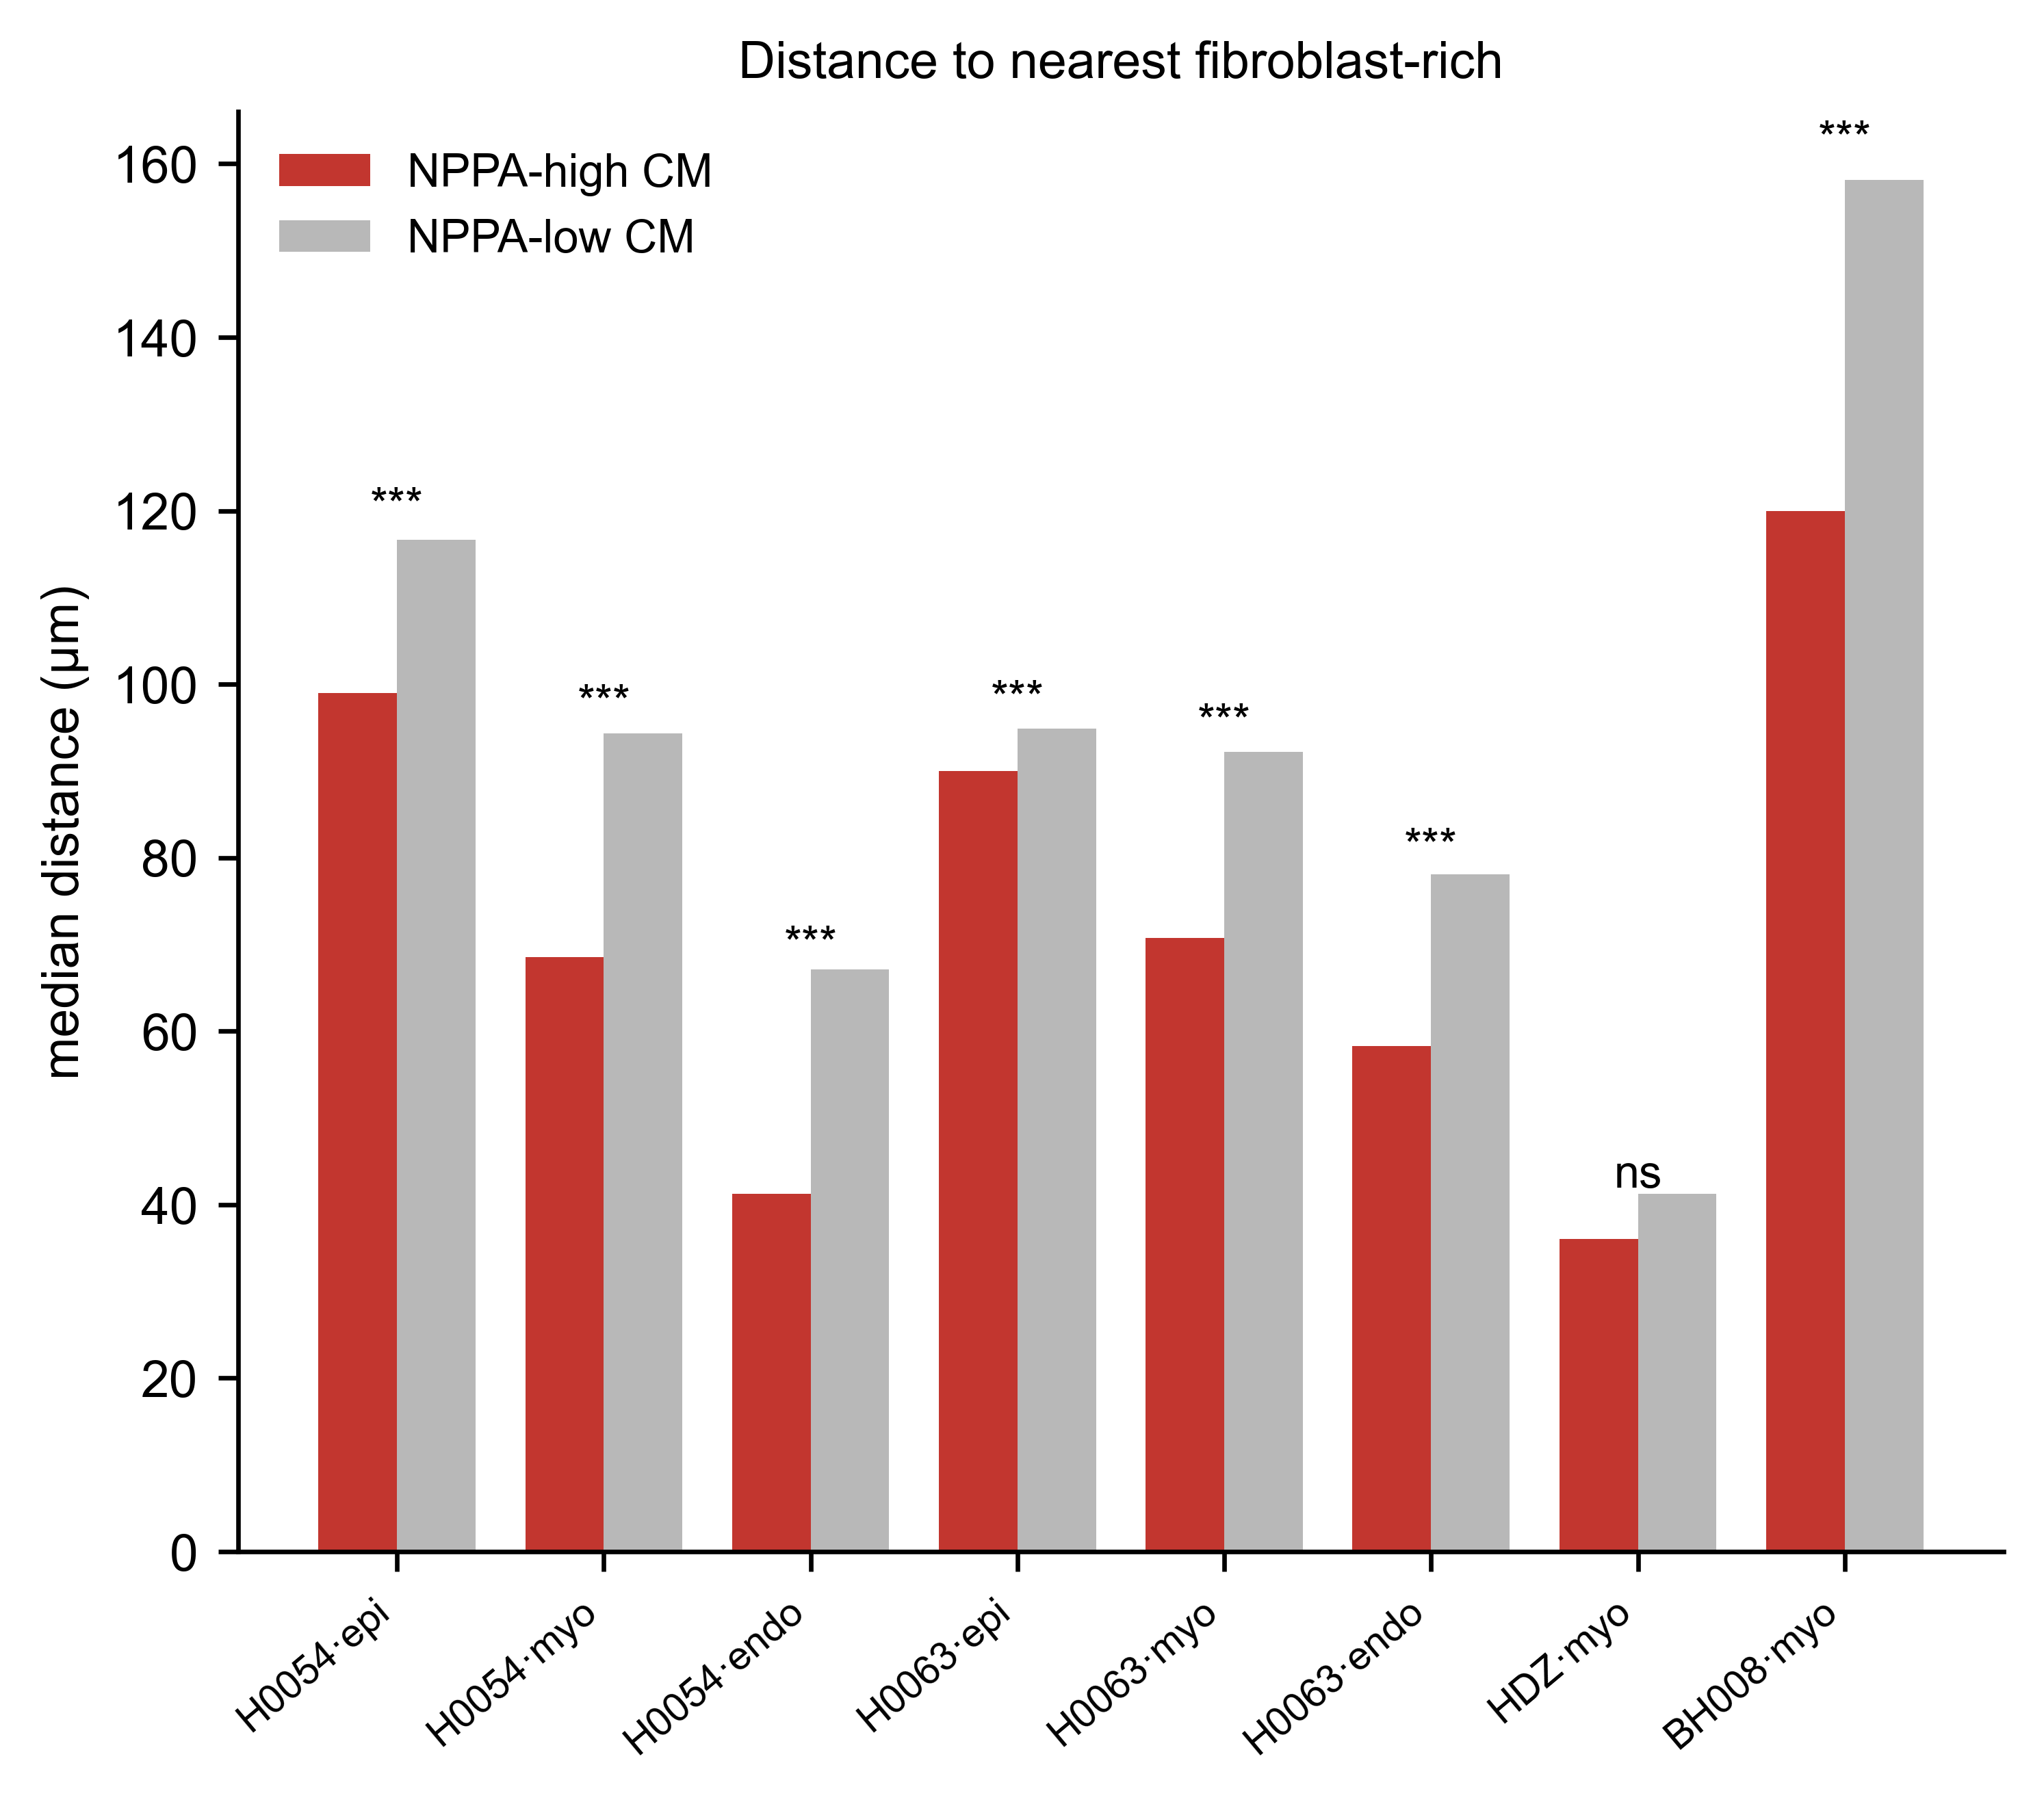

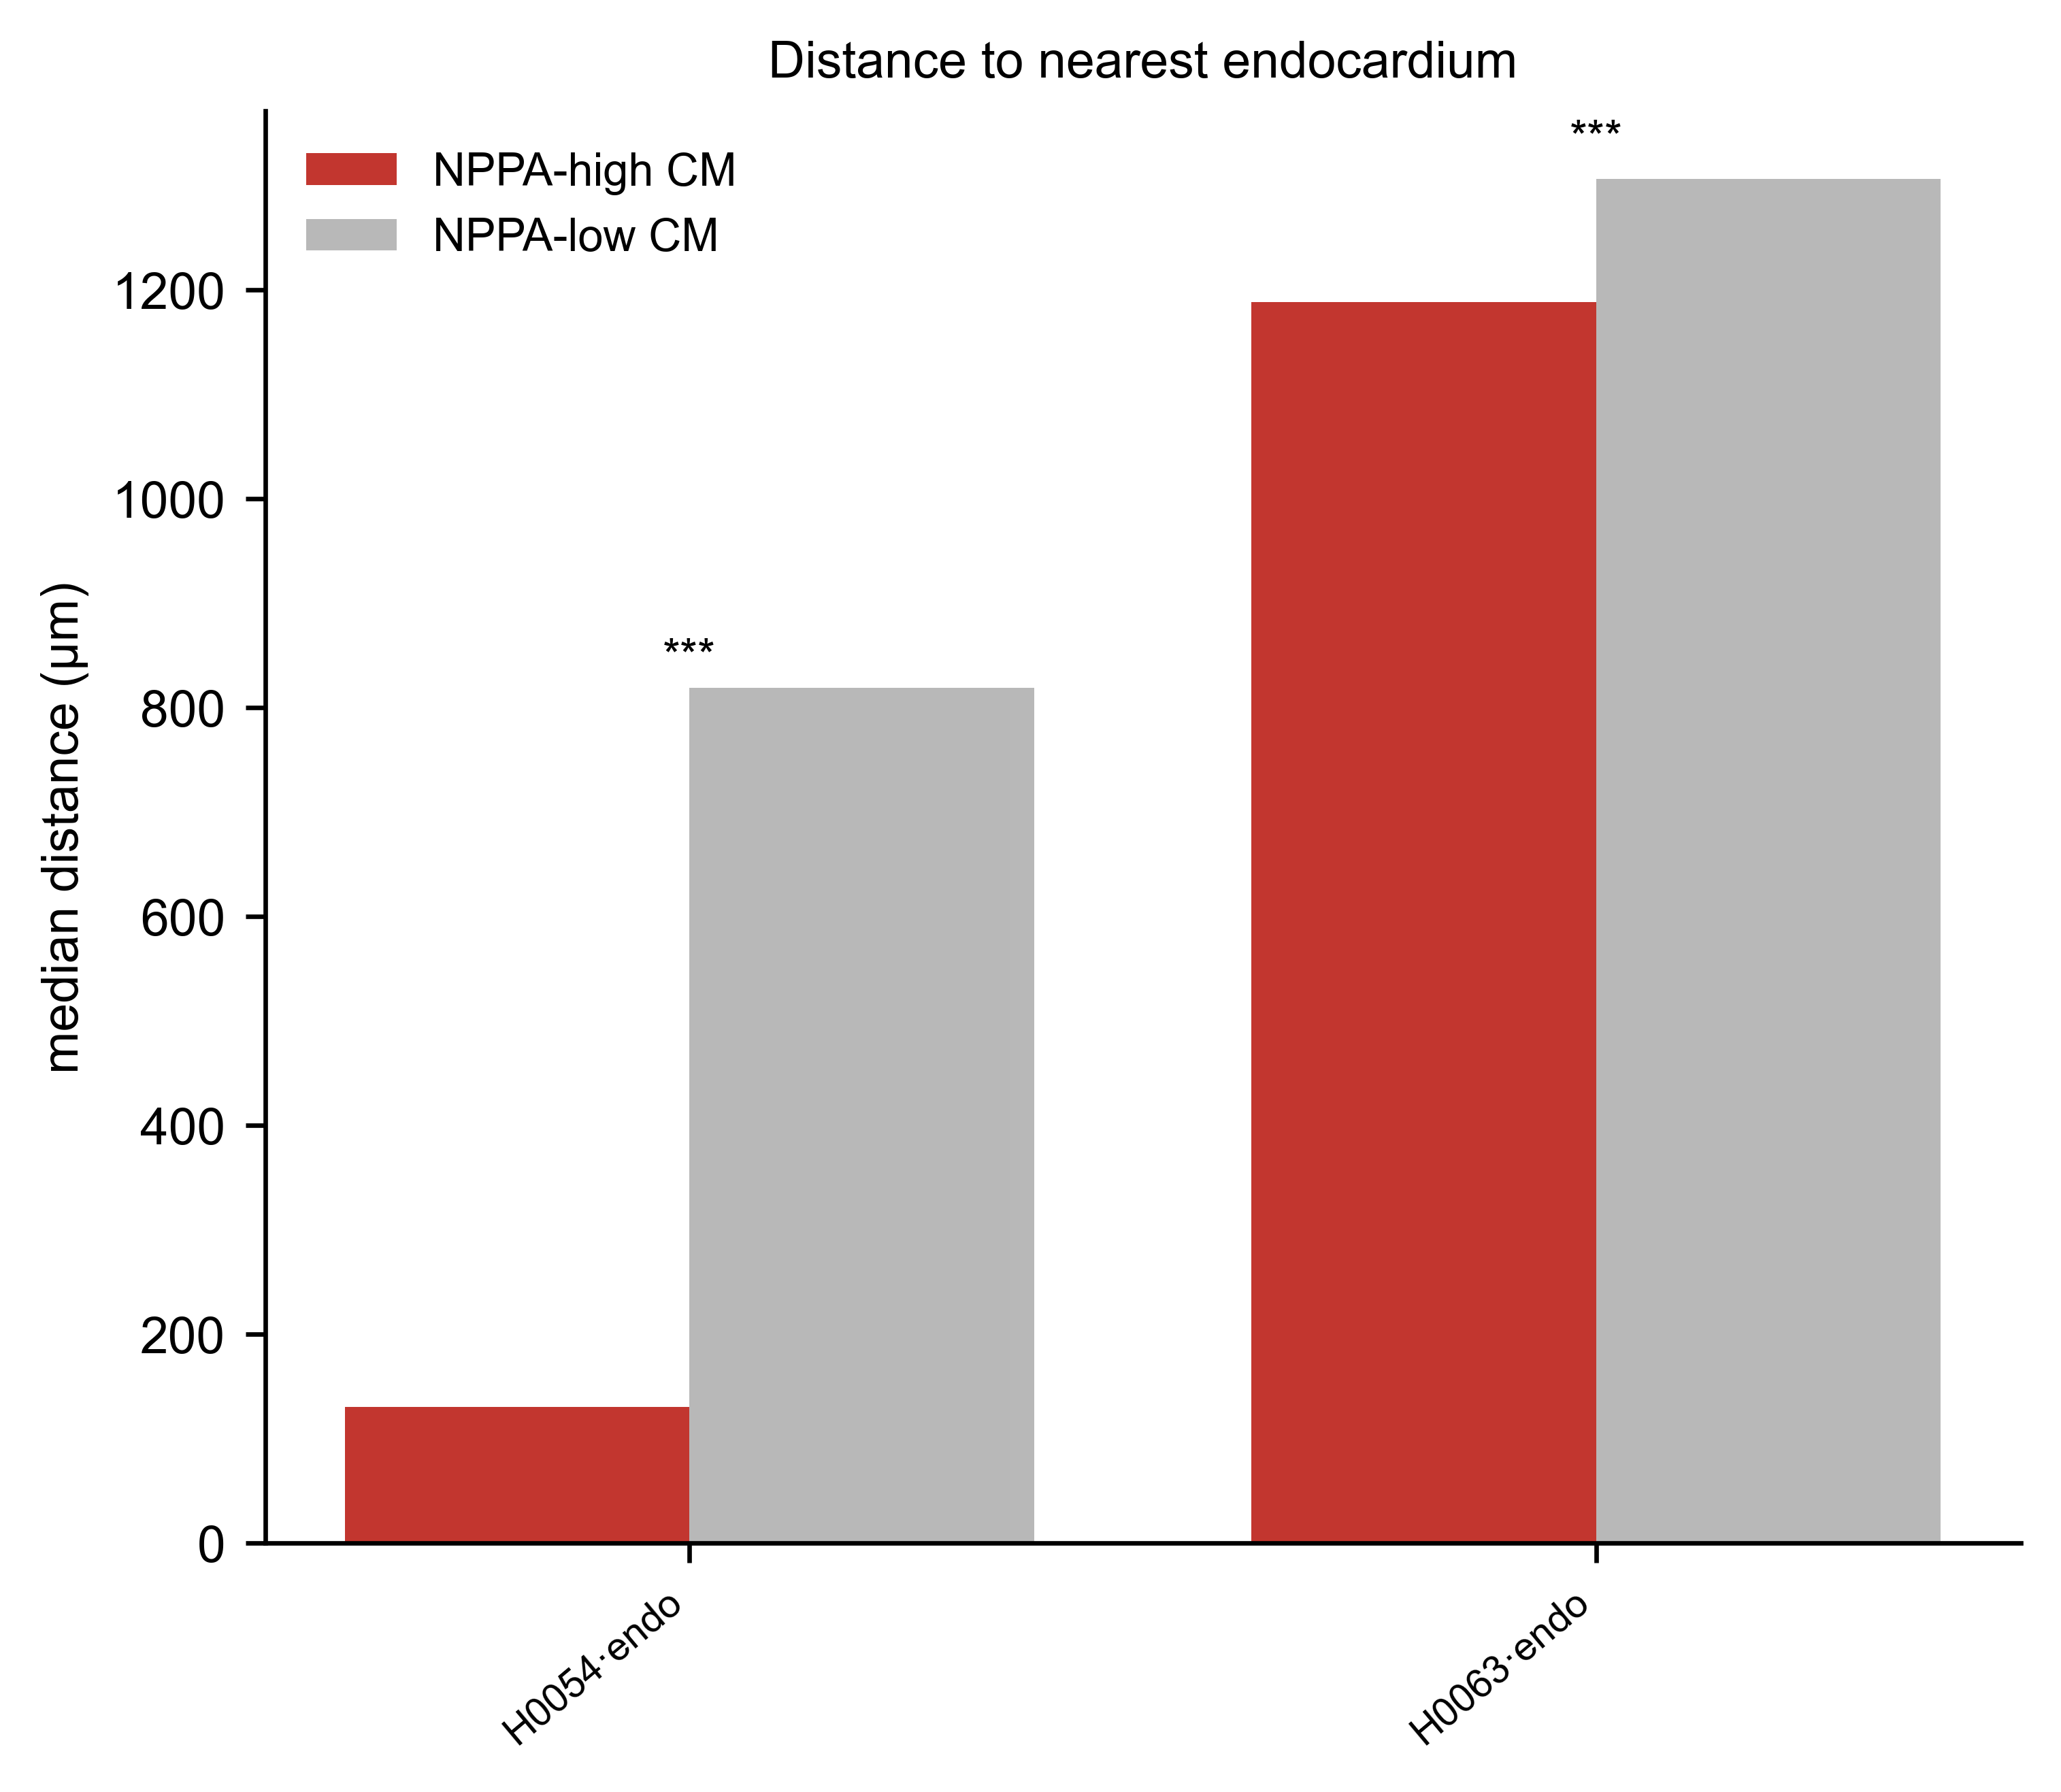

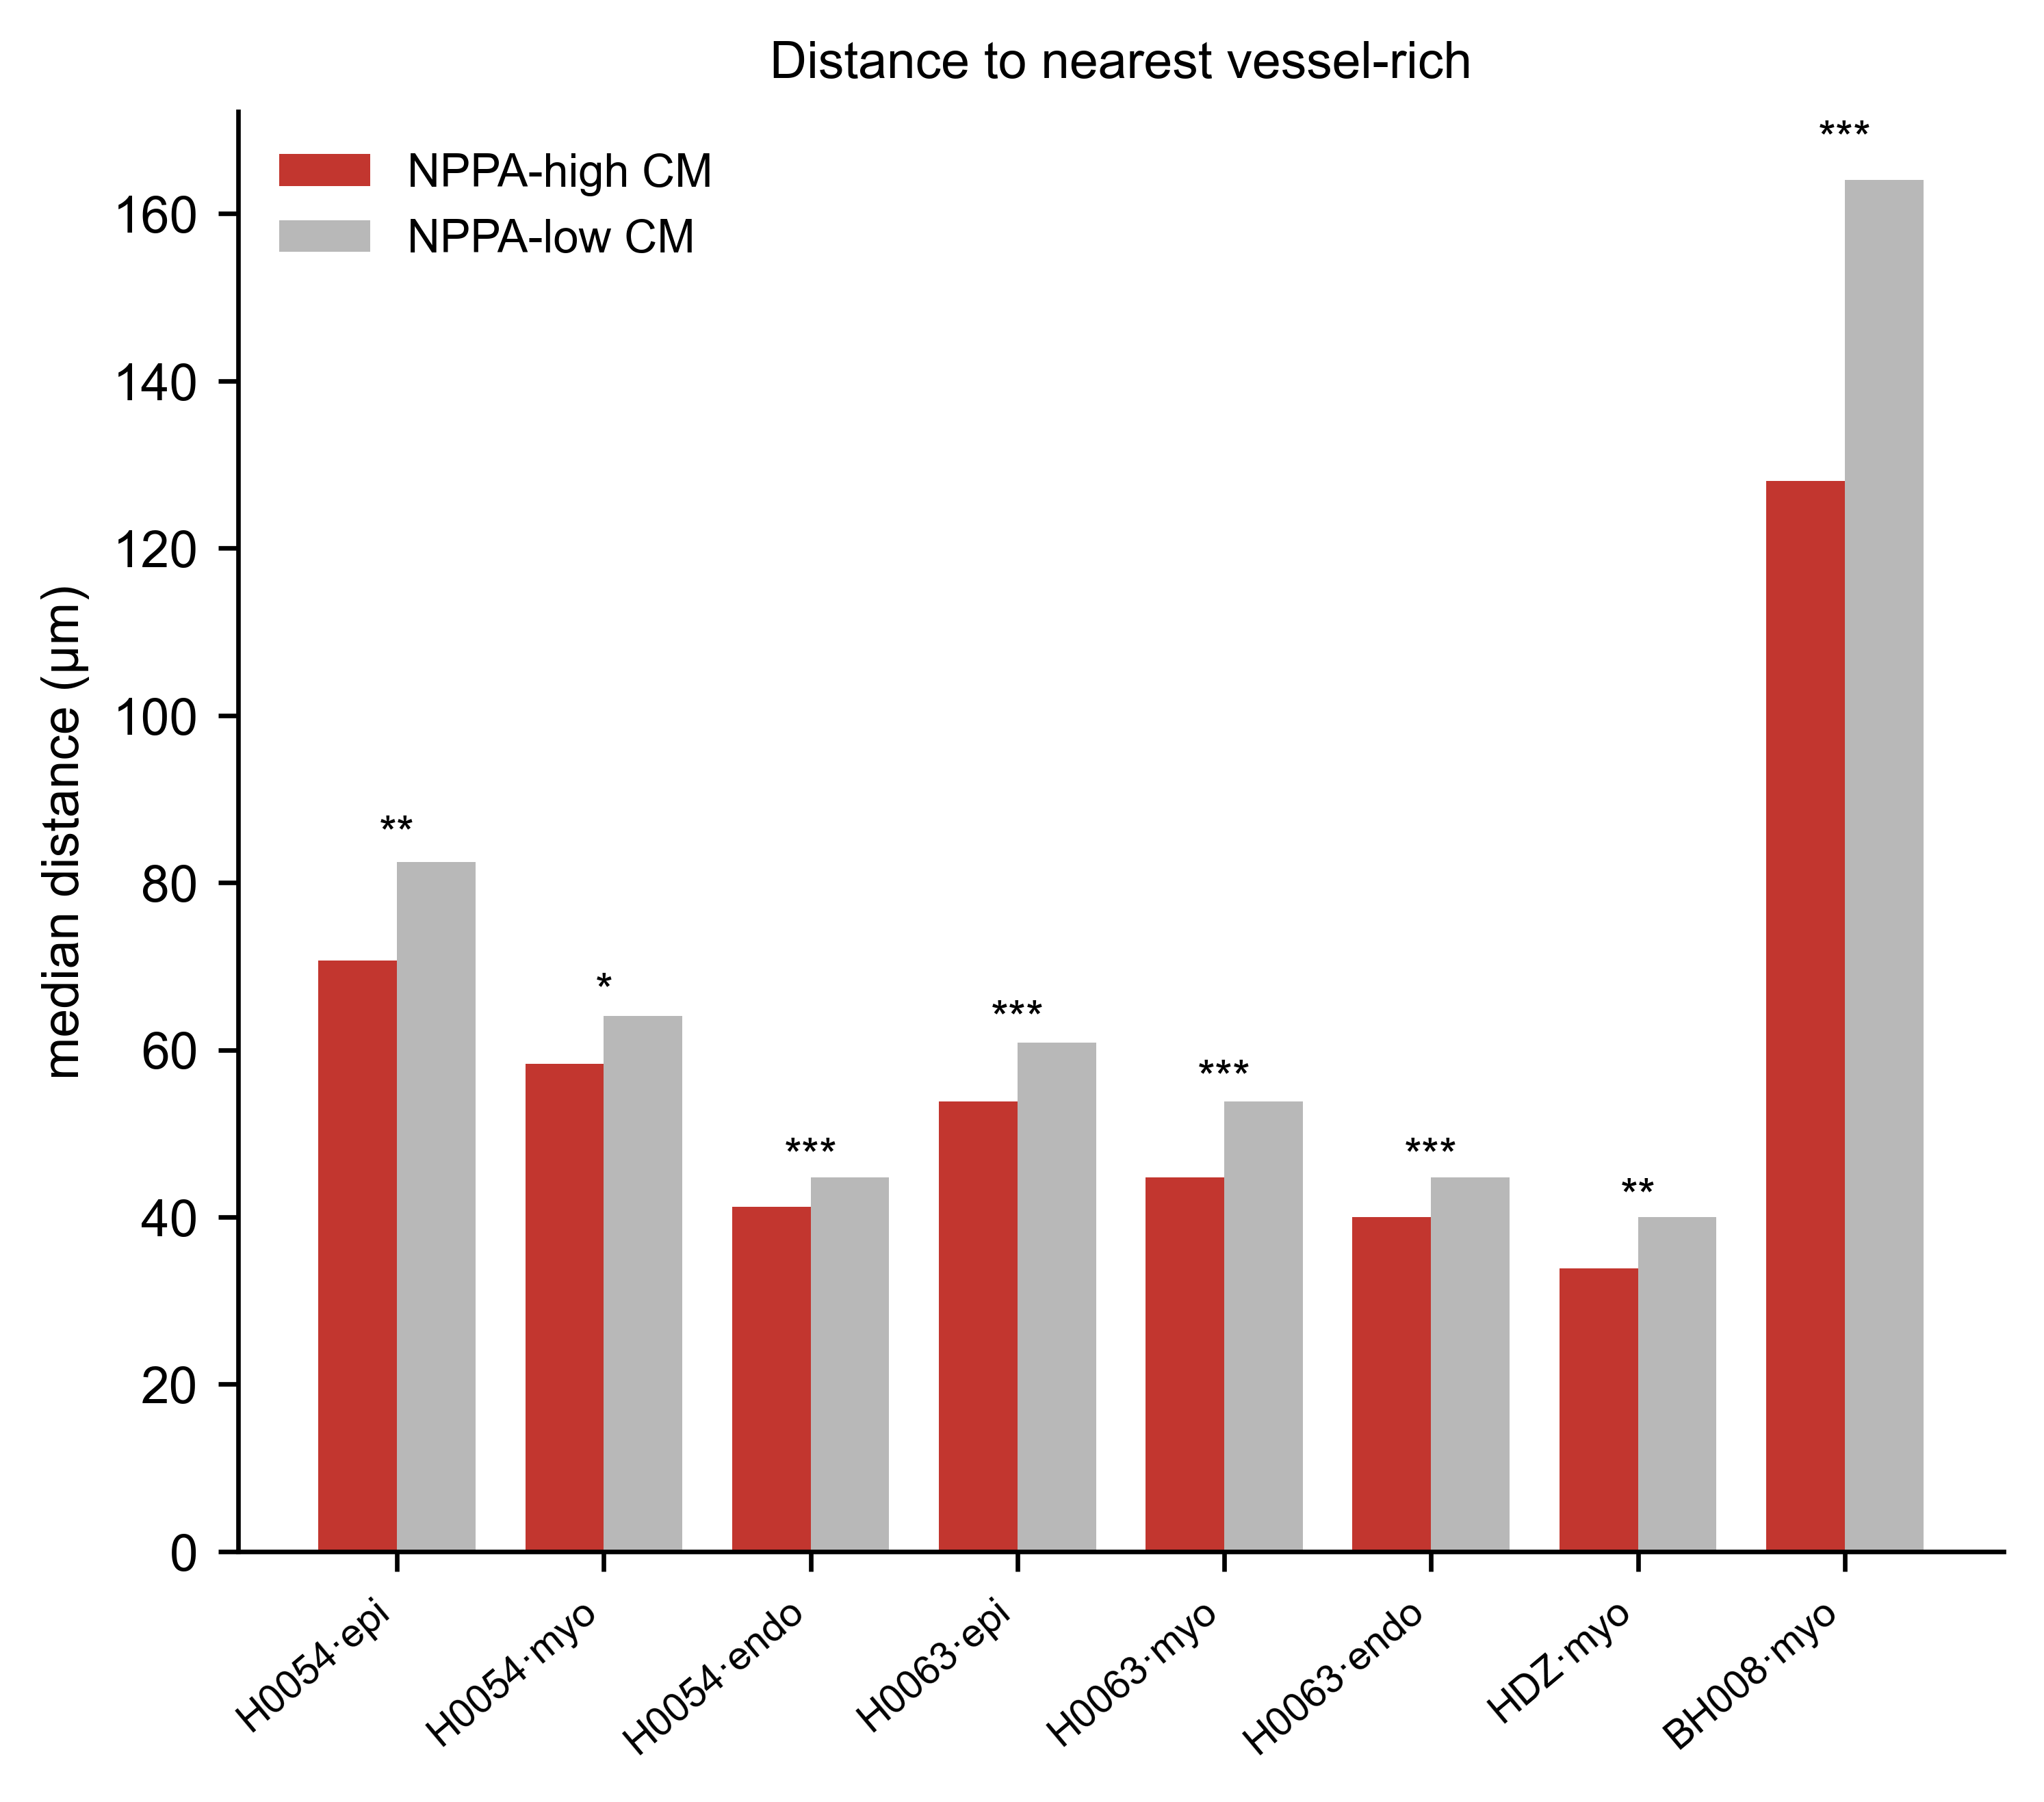

In [4]:
from hhca.paths import TABLES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pubfig import save

CSV = (f"{TABLES}/scanpy_analysis/MANUSCRIPT_STORY_FIGURES/Fig3_cardiomyocytes/nppa_niche_expanded/tables/"
       "niche_solidify_pooled.csv")
SLIDES = ["VS_CA_H0054LV_henricke_epi", "VS_CA_H0054LV_henricke_myo", "VS_CA_H0054LV_henricke_endo",
          "VS_CA_H0063LV_henricke_epi", "VS_CA_H0063LV_henricke_myo", "VS_CA_H0063LV_henricke_endo",
          "VS_BO_HDZ150319_34_myo", "VS_BO_2024BH-008_myo"]
ENDO_SLIDES = ["VS_CA_H0054LV_henricke_endo", "VS_CA_H0063LV_henricke_endo"]
SHORT = {"VS_CA_H0054LV_henricke_epi": "H0054·epi", "VS_CA_H0054LV_henricke_myo": "H0054·myo",
         "VS_CA_H0054LV_henricke_endo": "H0054·endo", "VS_CA_H0063LV_henricke_epi": "H0063·epi",
         "VS_CA_H0063LV_henricke_myo": "H0063·myo", "VS_CA_H0063LV_henricke_endo": "H0063·endo",
         "VS_BO_HDZ150319_34_myo": "HDZ·myo", "VS_BO_2024BH-008_myo": "BH008·myo"}
# source figure column order: fibroblast | endocardium | vessel ; manuscript letters f | h | g
PANELS = [("f", "dist_fibroblast_um", "fibroblast-rich", SLIDES),
          ("h", "dist_endocardial_um", "endocardium", ENDO_SLIDES),
          ("g", "dist_vessel_um", "vessel-rich", SLIDES)]

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "pdf.fonttype": 42, "ps.fonttype": 42})
pool = pd.read_csv(CSV)


def draw(ax, mkey, mlab, slides):
    order = [SHORT[s] for s in slides]
    sub = pool[(pool.metric == mkey) & (pool.gene == "NPPA")].set_index("short").reindex(order)
    x = np.arange(len(order))
    w = 0.38
    ax.bar(x - w / 2, sub.high_median.values, w, color="#C2362F", label="NPPA-high CM")
    ax.bar(x + w / 2, sub.low_median.values, w, color="0.72", label="NPPA-low CM")
    for xi, (_, r) in zip(x, sub.iterrows()):
        if np.isfinite(r.mw_q):
            star = "***" if r.mw_q < 1e-3 else ("**" if r.mw_q < 1e-2 else ("*" if r.mw_q < 0.05 else "ns"))
            ax.text(xi, max(r.high_median, r.low_median) * 1.02, star, ha="center", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=40, ha="right", fontsize=7)
    ax.set_ylabel("median distance (µm)")
    ax.set_title(f"Distance to nearest {mlab}", fontsize=9)
    ax.legend(frameon=False, fontsize=8)
    return sub


# one 1x3 figure exactly as the source, then each axes saved on its own (others removed)
for keep in range(3):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    subs = [draw(ax, mkey, mlab, slides) for ax, (_, mkey, mlab, slides) in zip(axes, PANELS)]
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    for i, ax in enumerate(axes):
        if i != keep:
            fig.delaxes(ax)
    letter = PANELS[keep][0]
    save(fig, "Fig3", letter, bbox_inches="tight")
    s = subs[keep]
    print(f"saved {letter} ({PANELS[keep][2]}): " +
          ", ".join(f"{i}={h:.0f}/{l:.0f}" for i, h, l in zip(s.index, s.high_median, s.low_median)))


## Fig3 i

Fig 3i — top cardiomyocyte transmural expression changes (data-driven marker search re-selected with AH10,

Input:
- `heart_results/module_curves_continuous/tables/traj_means_markersearch_withAH10_{H0054,H0063,AH10_cmflag}.csv`
- `heart_results/module_curves_continuous/tables/markersearch_genesets_withAH10.json`

Source: `figures/Fig3/panel_i.py`

saved i | endo-rising: ['ATP1A2', 'EHBP1L1', 'NCAM1', 'RAB13'] | epi-rising: ['RABGAP1L', 'KCNIP2', 'NMRK2', 'PPP1R1A']


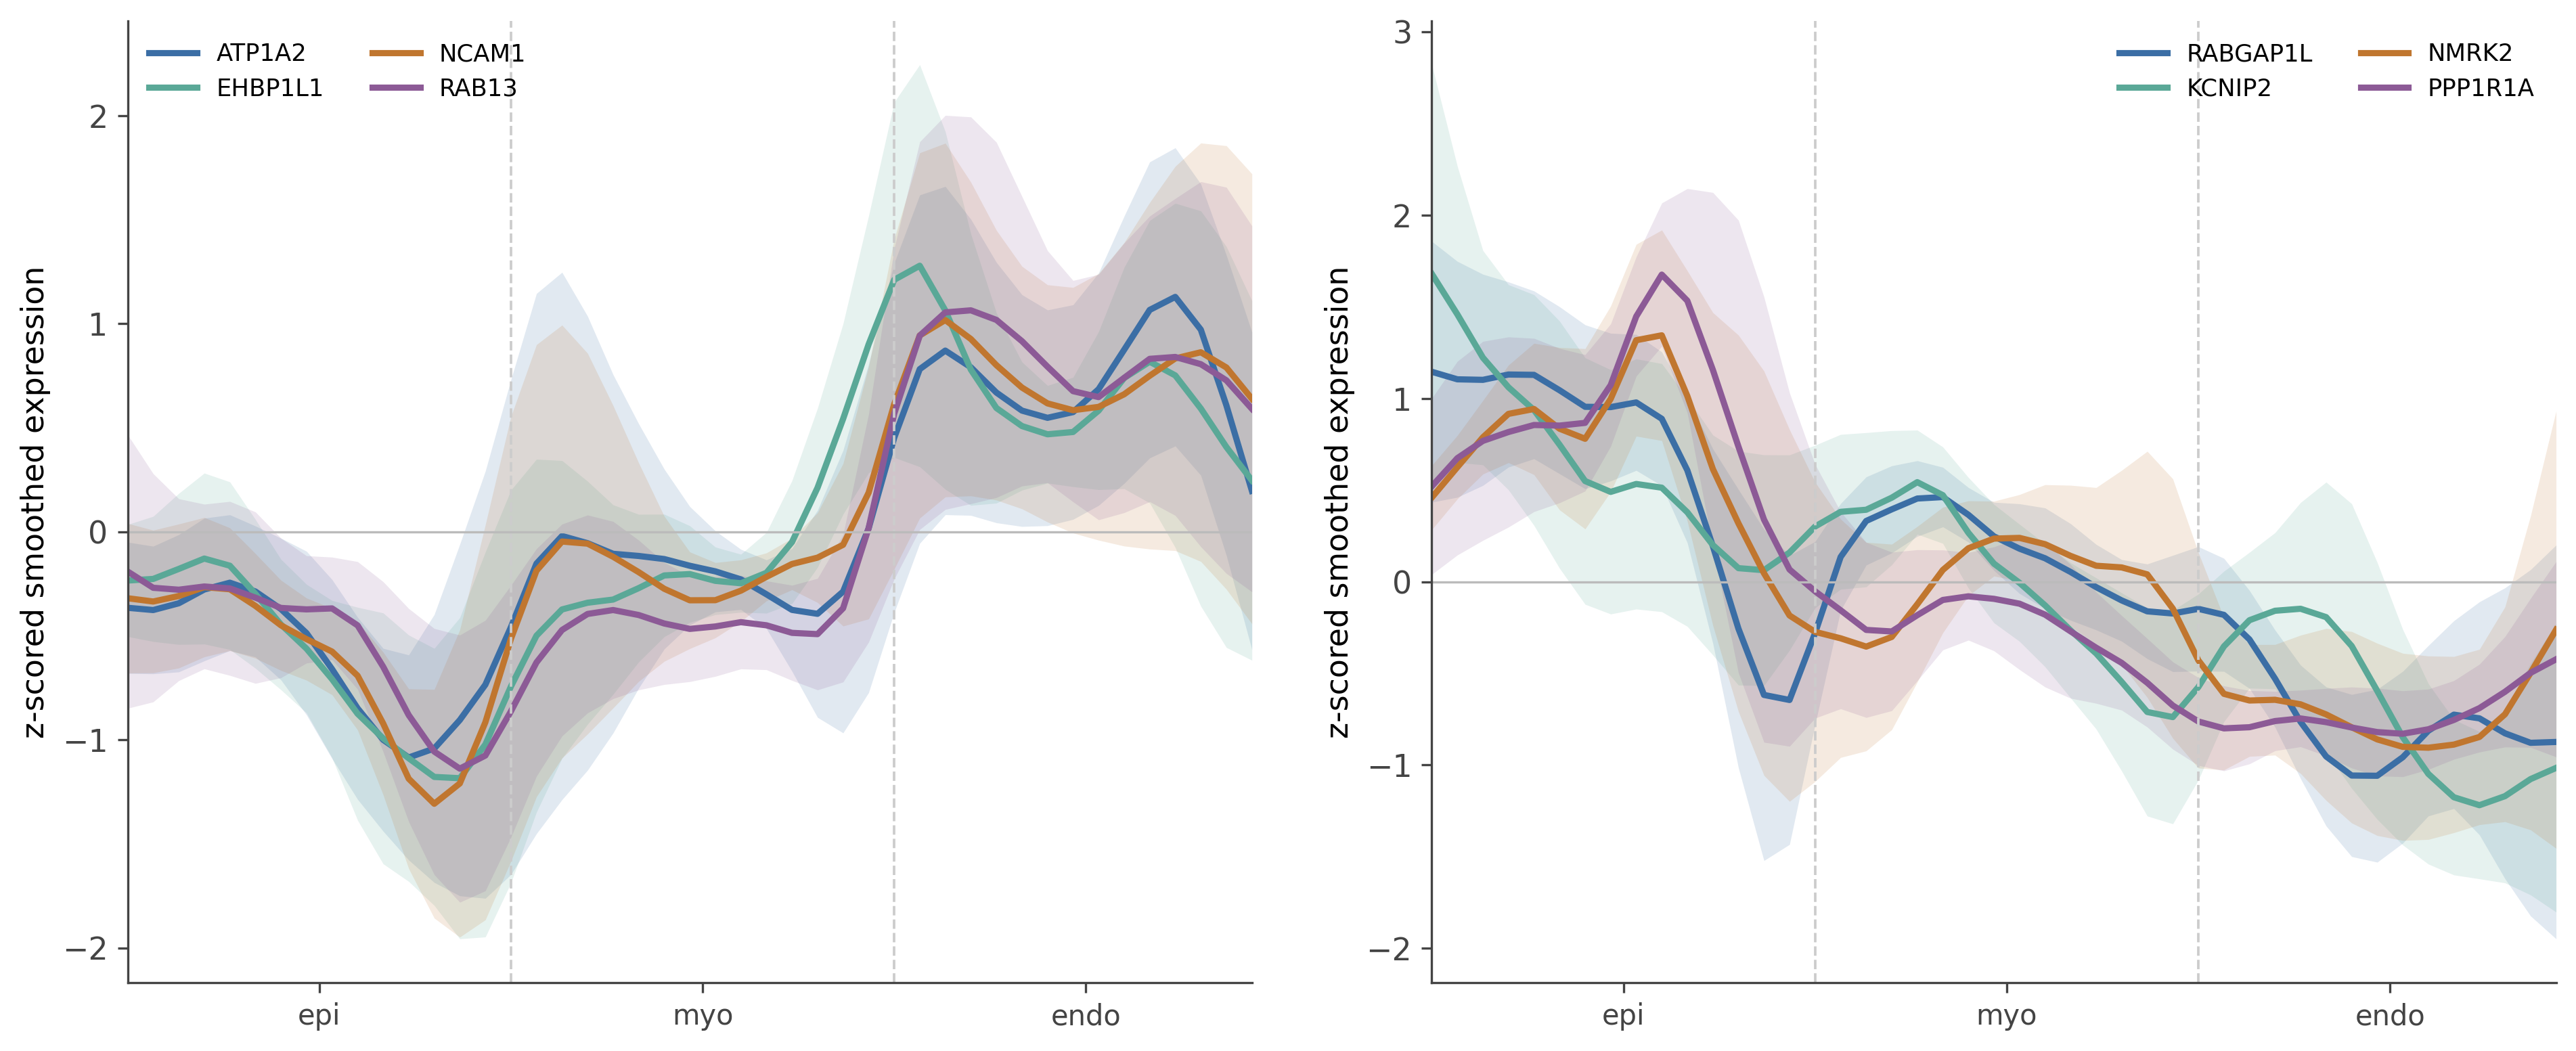

In [5]:
from hhca.paths import TABLES
import json
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from pubfig import save

TAB = f"{TABLES}/heart_results/module_curves_continuous/tables"
DONORS = ["H0054", "H0063", "AH10"]
SIGMA = 1.3
N_PER, N_BINS = 15, 45
SEP = [N_PER, 2 * N_PER]
XT = [N_PER * 0.5, N_PER * 1.5, N_PER * 2.5]
centers = np.arange(N_BINS)
MUTED = ["#3b6ea5", "#5aa897", "#c0762f", "#8c5a96", "#7a8b3b",
         "#b0506a", "#4f7f6f", "#a98b3a", "#6b6b8a", "#9c6b4a"]

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "DejaVu Sans", "figure.dpi": 150, "savefig.dpi": 300, "font.size": 11,
    "axes.edgecolor": "#444444", "axes.linewidth": 0.8, "axes.grid": False,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#444444", "ytick.color": "#444444", "pdf.fonttype": 42, "ps.fonttype": 42})

MSR = {d: pd.read_csv(f"{TAB}/traj_means_markersearch_withAH10_{'AH10_cmflag' if d == 'AH10' else d}.csv",
                      index_col=0) for d in DONORS}
BINCOLS = list(MSR["H0054"].columns)
MSR["AH10"].loc[:, BINCOLS[N_PER:2 * N_PER]] = np.nan      # AH10 has no mid-wall block
gm = json.load(open(f"{TAB}/markersearch_genesets_withAH10.json"))
ENDO = [g for g in gm["endo_module"] if g not in ("MMP2", "SPARC")]   # snRNA-CM-expressed only
EPI = gm["epi_module"]


def zscore_nan(a):
    a = np.asarray(a, float)
    s = np.nanstd(a)
    return (a - np.nanmean(a)) / s if s > 0 else a * 0.0


def smooth_nan(y, sigma):
    out = np.full_like(y, np.nan, float)
    fin = np.isfinite(y)
    i, n = 0, len(y)
    while i < n:
        if fin[i]:
            j = i
            while j < n and fin[j]:
                j += 1
            out[i:j] = y[i:j] if j - i == 1 else gaussian_filter1d(y[i:j], sigma, mode="nearest")
            i = j
        else:
            i += 1
    return out


def dmean(d, g):
    return MSR[d].loc[g, BINCOLS].values.astype(float) if g in MSR[d].index else np.full(N_BINS, np.nan)


def consensus3(g):
    Z = np.vstack([zscore_nan(dmean(d, g)) for d in DONORS])
    with np.errstate(invalid="ignore"):
        return np.nanmean(Z, axis=0), np.nanstd(Z, axis=0)


def panel(ax, genes):
    handles = []
    for i, g in enumerate(genes):
        c = MUTED[i % len(MUTED)]
        cons, spread = consensus3(g)
        cs, bs = smooth_nan(cons, SIGMA), smooth_nan(spread, SIGMA)
        m = np.isfinite(cs)
        ln, = ax.plot(centers[m], cs[m], color=c, lw=2.2, label=g)
        handles.append(ln)
        mb = np.isfinite(bs) & m
        ax.fill_between(centers[mb], (cs - bs)[mb], (cs + bs)[mb], color=c, alpha=0.15, lw=0)
    for b in SEP:
        ax.axvline(b, color="#cccccc", lw=0.9, ls="--")
    ax.axhline(0, color="#bbbbbb", lw=0.8)
    ax.set_ylabel("z-scored smoothed expression")
    ax.set_xticks(XT)
    ax.set_xticklabels(["epi", "myo", "endo"], fontsize=10)
    ax.set_xlim(0, N_BINS - 1)
    ax.margins(x=0.01)
    ax.legend(handles=handles, frameon=False, fontsize=8.5, ncol=2, loc="best")


fig, ax = plt.subplots(1, 2, figsize=(13.0, 6.4), sharex=True)
panel(ax[0], ENDO)
panel(ax[1], EPI)
fig.subplots_adjust(left=0.06, right=0.98, top=0.86, bottom=0.12, wspace=0.16)
save(fig, "Fig3", "i", bbox_inches="tight")
print("saved i | endo-rising:", ENDO, "| epi-rising:", EPI)
